In [2]:
import os
import ast

if 'PATH_SET' not in locals():
    os.chdir('../..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '1'
        os.environ['MKL_NUM_THREADS'] = '1'
        
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
        THREADS_SET = True
    except:
        pass

import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

In [ ]:
from helpers.geographic_setup import (
    design_space_shoulder,
    events_shoulder,
    picking_stats_shoulder,
    topo_data,
)

from helpers.helper_functions import concave_hull2D_prior_dist_constructor
from helpers.likelihood import DataLikelihood
from helpers.forward import TTLookup

In [4]:
vp_model_shoulder = xr.load_dataarray(
    'data/velocity_model/3d_model_final/vp_xarray.nc',
    engine='netcdf4',
    format='NETCDF4'
    )

In [5]:
SHOULDER_E_MIN = vp_model_shoulder['easting'].values.min()
SHOULDER_E_MAX = vp_model_shoulder['easting'].values.max()
SHOULDER_N_MIN = vp_model_shoulder['northing'].values.min()
SHOULDER_N_MAX = vp_model_shoulder['northing'].values.max()

dx = 10

topo_data = topo_data.interp(
    easting=np.arange(SHOULDER_E_MIN, SHOULDER_E_MAX, dx),
    northing=np.arange(SHOULDER_N_MIN, SHOULDER_N_MAX, dx),
)

z = torch.from_numpy(topo_data.values).float()

x_posterior = torch.arange(
    topo_data['easting'].values.min()+dx, topo_data['easting'].values.max()-dx, dx)
y_posterior = torch.arange(
    topo_data['northing'].values.min()+dx, topo_data['northing'].values.max()-dx, dx)
z_posterior = torch.from_numpy(
    topo_data.interp(easting=x_posterior, northing=y_posterior).values)

print(f'Posterior x: {x_posterior.min()} - {x_posterior.max()} ({x_posterior.shape[0]} points)')
print(f'Posterior y: {y_posterior.min()} - {y_posterior.max()} ({y_posterior.shape[0]} points)')
print(f'Posterior z: {z_posterior.min()} - {z_posterior.max()}')

Posterior x: 521.5400390625 - 1901.5400390625 (139 points)
Posterior y: 1141.6800537109375 - 1581.6800537109375 (45 points)
Posterior z: 1935.4761669621366 - 2352.0121661516464


In [6]:
X_posterior, Y_posterior = torch.meshgrid(
    x_posterior, y_posterior, indexing='ij')    

indices = torch.arange(z_posterior.numel())
posterior_grid = torch.stack(
    [X_posterior.ravel(), Y_posterior.ravel(),
     z_posterior.ravel(), indices], dim=-1)

torch.save(posterior_grid, 'data/priors/shoulder_posterior_grid.pt')

In [7]:
prior_dist = concave_hull2D_prior_dist_constructor(
    design_space_shoulder[..., :2],
    topo_data,
    buffer=0.0,
    depth=10.0,
    ratio=0.1,
)

In [ ]:
lookup_data = torch.load('data/data_lookup/heterogeneous_shoulder_posterior.pt')

forward_function_heterogenous =  TTLookup(
    posterior_grid, design_space_shoulder, lookup_data,
)

forward_function_shots =  TTLookup(
    events_shoulder, design_space_shoulder,
    torch.load('data/data_lookup/heterogeneous_shoulder_shots.pt'),
)

data_likelihood = DataLikelihood(
    forward_function=forward_function_heterogenous,
    dependence_distance=150,
    vel_sigma=0.05,
    tt_obs_std=0.01,
)

In [ ]:

data_likelihood = DataLikelihood(
    forward_function=forward_function_heterogenous,
    dependence_distance=0,
    vel_sigma=0.05,
    tt_obs_std=0.01,
)

In [10]:
design_df = pd.read_csv('generate_designs/data/design_data.csv')
design_df = design_df[design_df['study_area'] == 'shoulder']
# design_df = design_df.reset_index(drop=True)

print(f'Number of designs: {len(design_df)}')
print(f'Number of events : {len(events_shoulder)}')

Number of designs: 2085
Number of events : 94


In [11]:
tt_obs_file = 'data/picking_stats/shoulder_tt_obs.pt'

if not os.path.exists(tt_obs_file):
    tt_obs_collection = torch.full((len(events_shoulder), len(design_space_shoulder)), torch.nan)
    print(f'Number of TTs: {tt_obs_collection.numel()}')

    for d_i, design in tqdm(enumerate(design_space_shoulder), total=len(design_space_shoulder)):
        for e_i, event in enumerate(events_shoulder):
            try:
                tt_obs_collection[e_i, d_i] = picking_stats_shoulder[(
                    (picking_stats_shoulder['src_name'] == f'{event[0].item():4.0f}_{event[1].item():4.0f}') &
                    (picking_stats_shoulder['rec_name'] == f'{design[0].item():4.0f}_{design[1].item():4.0f}')
                )]['tt'].values[0]
            except:
                pass
    torch.save(tt_obs_collection, tt_obs_file)
else:
    tt_obs_collection = torch.load(tt_obs_file)


In [12]:
with torch.no_grad():
    log_p_prior_original = prior_dist.log_prob(posterior_grid, fast_eval=False)
    log_p_prior_original = log_p_prior_original.reshape(X_posterior.shape)

p_prior = log_p_prior_original.exp()
p_prior = p_prior / torch.nansum(p_prior) # for some reason prior is not normalized, do it here

prior_mask = log_p_prior_original.isfinite()

log_p_prior = p_prior.log()
log_p_prior[~prior_mask] = torch.nan

In [13]:
summary_file = 'benchmark_designs/shoulder/data/summary_statistics.csv'

if os.path.exists(summary_file):
    summary_statistics = pd.read_csv(summary_file)
else:
    for d_i, scen in tqdm(design_df.iterrows(), total=len(design_df)):
        
        summary_statistics = pd.DataFrame(
            columns=[
                'study_area', 'model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
                'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N', 'N_rec', 
                'design',
                'mean_x', 'mean_y', 'std_x', 'std_y', 
                'distance_mean', 'distance_map',
                'p_posterior', 'posterior_entropy', 'posterior_information',
                'prior_entropy', 'prior_information', 'event', 'event_index'
            ]
        )
        summary_statistics.to_csv('benchmark_designs/shoulder/data/summary_statistics.csv', index=False)

        def is_scenario_in_design_data(design_data, scen, N_rec):
            
            design_data = pd.DataFrame(design_data, columns=summary_statistics.columns)
            
            out =  ((design_data['study_area'] == scen['study_area']) &
                    (design_data['model_prior'] == scen['model_prior']) &
                    (design_data['velocity_model'] == scen['velocity_model']) &
                    (design_data['vel_sigma'] == scen['vel_sigma']) &
                    (design_data['noise_correlation'] == scen['noise_correlation']) &
                    (design_data['drop_mean'] == scen['drop_mean']) &
                    (design_data['drop_gradient'] == scen['drop_gradient']) &
                    (design_data['optimisation'] == scen['optimisation']) &
                    (design_data['EIG_method'] == scen['EIG_method']) &
                    (design_data['EIG_N'] == scen['EIG_N']) &
                    (design_data['N_rec'] == N_rec)).any()
            return out

        posterior_folder = f'benchmark_designs/shoulder/data/scenario_{scen["study_area"]}_{scen["model_prior"]}_{scen["velocity_model"]}_{scen["vel_sigma"]:.3f}_{scen["noise_correlation"]:.1f}_{scen["drop_mean"]:.1f}_{scen["drop_gradient"]:.1f}_{scen["optimisation"]}_{scen["EIG_method"]}_{scen["EIG_N"]}'
        os.makedirs(posterior_folder, exist_ok=True)
        
        design = torch.tensor(ast.literal_eval(scen['design']))
        receiver_indices = design[..., -1].int().tolist()
        
        posterior_stat_file = f'{posterior_folder}/posterior_stats.csv'
        
        if os.path.exists(posterior_stat_file):
            posterior_stat_df = pd.read_csv(posterior_stat_file)
        else:
            posterior_stat_df = pd.DataFrame(columns=list(summary_statistics.columns))
            posterior_stat_df.to_csv(posterior_stat_file, index=False)

        if is_scenario_in_design_data(posterior_stat_df, scen, len(receiver_indices)):
            # print('Scenario already in design data')
            pass
        else:
            for e_i, event in tqdm(enumerate(events_shoulder), total=len(events_shoulder), desc=f'Scenario {d_i}', leave=False):
            
                tt_obs = tt_obs_collection[e_i, receiver_indices]
                design_tmp = design[tt_obs.isfinite()]
                tt_obs = tt_obs[tt_obs.isfinite()]
                
                obs_cov = data_likelihood.cov(
                    tt_obs.unsqueeze(0).double(),
                    model_samples    = events_shoulder.unsqueeze(0).double(),
                    design           = design_tmp.double(),
                )
            
                if len(tt_obs) < 1:
                    log_p_posterior = log_p_prior.clone()
                else:
                    log_p_likelihood = data_likelihood(
                        posterior_grid[prior_mask.flatten()], design_tmp,
                        posterior_cov=obs_cov,
                        ).log_prob(tt_obs)
                    
                    log_p_unnormalised_posterior = log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
                    log_p_evidence = torch.logsumexp(log_p_unnormalised_posterior, dim=0)
                    
                    log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
                    log_p_posterior[prior_mask.flatten()] = log_p_unnormalised_posterior - log_p_evidence
                    log_p_posterior = log_p_posterior.reshape(X_posterior.shape)
                
                p_prior = log_p_prior.exp()
                p_posterior = log_p_posterior.exp()    

                p_prior = torch.nan_to_num(p_prior, nan=0.0)
                p_posterior = torch.nan_to_num(p_posterior, nan=0.0)
                
                # Calculate mean (expected value)
                mean_x = (X_posterior * p_posterior).sum() / p_posterior.sum()
                mean_y = (Y_posterior * p_posterior).sum() / p_posterior.sum()
                
                # Calculate standard deviation
                std_x = torch.sqrt(((X_posterior - mean_x)**2 * p_posterior).sum() / p_posterior.sum())
                std_y = torch.sqrt(((Y_posterior - mean_y)**2 * p_posterior).sum() / p_posterior.sum())
                
                # Calculate distance from mean to true event
                squared_dist_mean_x = (mean_x - event[0])**2
                squared_dist_mean_y = (mean_y - event[1])**2
                distance_mean = torch.sqrt(squared_dist_mean_x + squared_dist_mean_y)
                
                # Find MAP (maximum a posteriori)
                max_idx = torch.argmax(p_posterior)
                map_x = X_posterior.flatten()[max_idx]
                map_y = Y_posterior.flatten()[max_idx]
                
                # Calculate distance from MAP to true event
                squared_dist_map_x = (map_x - event[0])**2
                squared_dist_map_y = (map_y - event[1])**2
                distance_map = torch.sqrt(squared_dist_map_x + squared_dist_map_y)
                
                # Get posterior probability at true event location
                interp = RegularGridInterpolator(
                    (x_posterior, y_posterior), p_posterior.numpy())
                post_p = interp(event[:2]).item()
                
                # Calculate entropy and information
                entropy_terms = torch.log(p_posterior) * p_posterior
                post_entropy = -torch.nansum(entropy_terms)
                post_info = -post_entropy
                
                entropy_terms_prior = torch.log(p_prior) * p_prior
                prior_entropy = -torch.nansum(entropy_terms_prior)
                prior_info = -prior_entropy
                
                posterior_stat_df.loc[len(posterior_stat_df)] = [
                    scen['study_area'], scen['model_prior'], scen['velocity_model'], scen['vel_sigma'], scen['noise_correlation'],
                    scen['drop_mean'], scen['drop_gradient'], scen['optimisation'], scen['EIG_method'], scen['EIG_N'], scen['N_rec'],
                    design.tolist(),
                    mean_x.item(), mean_y.item(), std_x.item(), std_y.item(),
                    distance_mean.item(), distance_map.item(),
                    post_p, post_entropy.item(), post_info.item(), prior_entropy.item(), prior_info.item(),
                    event, e_i
                ]
            
        posterior_stat_df.to_csv(posterior_stat_file, index=False)


    # Initialize a list to store all dataframes
    all_dfs = []

    # Look for posterior_stat files in the benchmark_designs/shoulder/data directories
    for root, dirs, files in os.walk('benchmark_designs/shoulder/data'):
        for dir_name in dirs:
            if dir_name.startswith('scenario_'):
                posterior_stat_file = os.path.join(root, dir_name, 'posterior_stats.csv')
                if os.path.exists(posterior_stat_file):
                    try:
                        # Read the dataframe
                        df = pd.read_csv(posterior_stat_file)
                                        
                        all_dfs.append(df)
                        # print(f"Processed {posterior_stat_file}")
                    except Exception as e:
                        print(f"Error processing {posterior_stat_file}: {e}")

    # Combine all dataframes
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        
        # Update the summary_statistics dataframe
        summary_statistics = combined_df
        
        # Save the updated summary statistics
        summary_statistics.to_csv(summary_file, index=False)
        
        print(f"Combined {len(all_dfs)} posterior statistic files into summary_statistics.csv")
        print(f"Total number of entries: {len(summary_statistics)}")
    else:
        print("No posterior statistic files found to process.")
        
        
summary_statistics[
    summary_statistics['drop_gradient'] == -13.0
] = -15.0

  0%|          | 0/2085 [00:00<?, ?it/s]

Scenario 9:   0%|          | 0/94 [00:00<?, ?it/s]

Scenario 10:   0%|          | 0/94 [00:00<?, ?it/s]

Scenario 11:   0%|          | 0/94 [00:00<?, ?it/s]

Scenario 12:   0%|          | 0/94 [00:00<?, ?it/s]

...

Scenario 5474:   0%|          | 0/94 [00:00<?, ?it/s]

Scenario 5475:   0%|          | 0/94 [00:00<?, ?it/s]

Scenario 5476:   0%|          | 0/94 [00:00<?, ?it/s]

Scenario 5477:   0%|          | 0/94 [00:00<?, ?it/s]

Combined 172 posterior statistic files into summary_statistics.csv
Total number of entries: 193546


In [14]:
import os

random_stats_file = 'benchmark_designs/shoulder/data/random_stats.csv'
sobol_stats_file = 'benchmark_designs/shoulder/data/sobol_stats.csv'

def calc_random_stats(design_sampler, design_space, N_random=1000, N_rec_min=2, N_rec_max=15, method_name='random'):
    stats = []
    torch.manual_seed(0)
    for N_rec in tqdm(range(N_rec_min, N_rec_max+1), desc='Calculating random stats'):
        for i in range(N_random):
            # Sample random design
            design = design_sampler(N_rec)
            # For each design, find closest in design_space
            indices = torch.cdist(design.unsqueeze(0)[..., :3], design_space[..., :3]).argmin(dim=-1)
            design_selected = design_space[indices].squeeze(0)
            # For each event, get tt_obs
            for e_i, event in enumerate(events_shoulder):
                tt_obs = tt_obs_collection[e_i, indices.squeeze(0)]
                design_tmp = design_selected[tt_obs.isfinite()]
                tt_obs_valid = tt_obs[tt_obs.isfinite()]
                obs_cov = data_likelihood.cov(
                    tt_obs_valid.unsqueeze(0).double(),
                    model_samples=events_shoulder.unsqueeze(0).double(),
                    design=design_tmp.double(),
                )
                if len(tt_obs_valid) < 1:
                    log_p_posterior = log_p_prior.clone()
                else:
                    log_p_likelihood = data_likelihood(
                        posterior_grid[prior_mask.flatten()], design_tmp,
                        posterior_cov=obs_cov,
                    ).log_prob(tt_obs_valid)
                    log_p_unnormalised_posterior = log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
                    log_p_evidence = torch.logsumexp(log_p_unnormalised_posterior, dim=0)
                    log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
                    log_p_posterior[prior_mask.flatten()] = log_p_unnormalised_posterior - log_p_evidence
                    log_p_posterior = log_p_posterior.reshape(X_posterior.shape)
                p_prior = log_p_prior.exp()
                p_posterior = log_p_posterior.exp()
                p_prior = torch.nan_to_num(p_prior, nan=0.0)
                p_posterior = torch.nan_to_num(p_posterior, nan=0.0)
                mean_x = (X_posterior * p_posterior).sum() / p_posterior.sum()
                mean_y = (Y_posterior * p_posterior).sum() / p_posterior.sum()
                std_x = torch.sqrt(((X_posterior - mean_x)**2 * p_posterior).sum() / p_posterior.sum())
                std_y = torch.sqrt(((Y_posterior - mean_y)**2 * p_posterior).sum() / p_posterior.sum())
                squared_dist_mean_x = (mean_x - event[0])**2
                squared_dist_mean_y = (mean_y - event[1])**2
                distance_mean = torch.sqrt(squared_dist_mean_x + squared_dist_mean_y)
                max_idx = torch.argmax(p_posterior)
                map_x = X_posterior.flatten()[max_idx]
                map_y = Y_posterior.flatten()[max_idx]
                squared_dist_map_x = (map_x - event[0])**2
                squared_dist_map_y = (map_y - event[1])**2
                distance_map = torch.sqrt(squared_dist_map_x + squared_dist_map_y)
                from scipy.interpolate import RegularGridInterpolator
                interp = RegularGridInterpolator(
                    (x_posterior, y_posterior), p_posterior.numpy())
                post_p = interp(event[:2]).item()
                entropy_terms = torch.log(p_posterior) * p_posterior
                post_entropy = -torch.nansum(entropy_terms)
                post_info = -post_entropy
                entropy_terms_prior = torch.log(p_prior) * p_prior
                prior_entropy = -torch.nansum(entropy_terms_prior)
                prior_info = -prior_entropy
                stats.append(dict(
                    method=method_name,
                    N_rec=N_rec,
                    design=design_selected.tolist(),
                    mean_x=mean_x.item(),
                    mean_y=mean_y.item(),
                    std_x=std_x.item(),
                    std_y=std_y.item(),
                    distance_mean=distance_mean.item(),
                    distance_map=distance_map.item(),
                    p_posterior=post_p,
                    posterior_entropy=post_entropy.item(),
                    posterior_information=post_info.item(),
                    prior_entropy=prior_entropy.item(),
                    prior_information=prior_info.item(),
                    event=event.tolist(),
                    event_index=e_i,
                ))
    return pd.DataFrame(stats)

# Check if files exist, else compute and save
if os.path.exists(random_stats_file):
    random_stats_df = pd.read_csv(random_stats_file)
else:
    def uniform_sampler(N_rec):
        idx = torch.randint(len(design_space_shoulder), (N_rec,))
        return design_space_shoulder[idx]
    random_stats_df = calc_random_stats(uniform_sampler, design_space_shoulder, N_random=1000, N_rec_min=2, N_rec_max=15, method_name='random')
    random_stats_df.to_csv(random_stats_file, index=False)

if os.path.exists(sobol_stats_file):
    sobol_stats_df = pd.read_csv(sobol_stats_file)
else:
    def sobol_sampler(N_rec):
        design_space_dist = concave_hull2D_prior_dist_constructor(
            design_space_shoulder[..., :3], topo_data,
            base_dist='sobol',
            buffer=20, depth=0, ratio=0.05,
        )
        return design_space_dist.sample(N_rec).float()
    sobol_stats_df = calc_random_stats(sobol_sampler, design_space_shoulder, N_random=1000, N_rec_min=2, N_rec_max=15, method_name='sobol')
    sobol_stats_df.to_csv(sobol_stats_file, index=False)

In [15]:
# Add design_index to random_stats_df and sobol_stats_df
# design_index is the index within each (N_rec, event_index) group

def add_design_index(df):
    # If already present, do not add again
    if 'design_index' in df.columns:
        return df
    # Assign design_index within each (N_rec, event_index) group
    df = df.copy()
    df['design_index'] = (
        df.groupby(['N_rec', 'event_index']).cumcount()
    )
    return df

random_stats_df = add_design_index(random_stats_df)
sobol_stats_df = add_design_index(sobol_stats_df)

# Get Combined Statistics

In [16]:
scen_columns = [
    'study_area', 'model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
    'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N',
]

stat_columns = [
    'mean_x', 'mean_y',
    'std_x', 'std_y',
    'distance_mean', 'distance_map',
    'p_posterior', 'posterior_entropy', 'posterior_information',
    'prior_entropy', 'prior_information',
]     

In [17]:
# N_rec_min = random_stats_df['N_rec'].min()
N_rec_min = 4
N_rec_max = 10 # careful if this is above EIG_N > 1000 not working anymore

In [18]:
import numpy as np

# Filter for N_rec in the desired range
df_filtered = summary_statistics[
    (summary_statistics['N_rec'] >= N_rec_min) & (summary_statistics['N_rec'] <= N_rec_max)
]
df_filtered = df_filtered.drop(columns='design')
# First, group by scenario columns and N_rec, then average over events
grouped = df_filtered.groupby(scen_columns+['N_rec'])[stat_columns].mean().reset_index()

# Add EIG values from design_df to grouped by matching scenario columns and N_rec
grouped = grouped.copy()
grouped['EIG'] = np.nan

for idx, row in grouped.iterrows():
    # Find matching scenario in design_df, including N_rec
    mask = True
    for col in scen_columns + ['N_rec']:
        mask &= (design_df[col] == row[col])
    df_match = design_df[mask]
        
    if not df_match.empty:
        eig_value = df_match.iloc[0]['EIG_ref']
        grouped.at[idx, 'EIG'] = eig_value

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(grouped.head(100))
    
agg_stats = grouped.groupby(scen_columns).agg({
    'EIG': 'mean',
    'mean_x': 'mean',
    'mean_y': 'mean',
    'std_x': 'mean',
    'std_y': 'mean',
    'distance_mean': 'mean',
    'distance_map': 'mean',
    'p_posterior': 'mean',
    'posterior_entropy': 'mean',
    'posterior_information': 'mean',
    'prior_entropy': 'mean',
    'prior_information': 'mean'
}).reset_index()

print(f'Number of aggregated scenarios: {len(agg_stats)}')

agg_stats = agg_stats[
    (((agg_stats['EIG_method'] == 'DN') & (agg_stats['drop_mean'] == 0.0)) |
        ((agg_stats['EIG_method'] == 'NMC')))
]

print(f'Number of aggregated scenarios: {len(agg_stats)}')


Number of aggregated scenarios: 166
Number of aggregated scenarios: 154


In [19]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(agg_stats.head(100))

In [20]:
# First, group by N_rec and event_index, then average over events for each design_index
random_grouped = (
    random_stats_df[(random_stats_df['N_rec'] >= N_rec_min) & (random_stats_df['N_rec'] <= N_rec_max)]
    .groupby(['N_rec', 'design_index',])[stat_columns].mean()
    .groupby(['design_index'])[stat_columns].mean()
    .reset_index()
)

sobol_grouped = (
    sobol_stats_df[(sobol_stats_df['N_rec'] >= N_rec_min) & (sobol_stats_df['N_rec'] <= N_rec_max)]
    .groupby(['N_rec', 'design_index',])[stat_columns].mean()
    .groupby(['design_index'])[stat_columns].mean()
    .reset_index()
)

# Add EIG values from design_df to random_grouped and sobol_grouped

import numpy as np

def add_eig_to_grouped(grouped_df, method, design_df):
    # Filter design_df for the correct method
    df = design_df[
        (design_df['optimisation'] == method) &
        (design_df['velocity_model'] == 'gradient') &
        (design_df['drop_mean'] == 0.35)
    ].copy()
    # Convert EIG_candidates column to arrays

    eig_arrays = np.array([np.array(ast.literal_eval(eig)) for eig in df['EIG_candidates'].values])
    print(eig_arrays.shape)

    eig_arrays = eig_arrays.mean(axis=0)  # Average over samples

    print(eig_arrays.shape)
    # If there are more EIG candidates than designs, take only the first N
    N = len(grouped_df)
    eig_arrays = eig_arrays[:N]

    grouped_df = grouped_df.copy()
    grouped_df['EIG'] = eig_arrays
    return grouped_df

random_grouped = add_eig_to_grouped(random_grouped, 'random', design_df)
sobol_grouped = add_eig_to_grouped(sobol_grouped, 'sobol', design_df)

# Display or use as needed
print("Random stats (aggregated):")
print(random_grouped.shape)

print("Sobol stats (aggregated):")
print(sobol_grouped.shape)

(14, 1000)
(1000,)
(14, 1000)
(1000,)
Random stats (aggregated):
(1000, 13)
Sobol stats (aggregated):
(1000, 13)


In [21]:
'velocity_model', 'vel_sigma', 'noise_correlation', 'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N'

('velocity_model',
 'vel_sigma',
 'noise_correlation',
 'drop_mean',
 'drop_gradient',
 'optimisation',
 'EIG_method',
 'EIG_N')

In [ ]:
from matplotlib.lines import Line2D


def plot_combinations(
    ax,
    data,
    x_quantity,
    y_quantity,
    param1,
    param2=None,
    color_dict=None,
    marker_dict=None,
    random_grouped=random_grouped,
    sobol_grouped=sobol_grouped,
    background_alpha=0.35,
    title=None,
    attenuation=None,
    set_defaults=True,
    select_matching=False
):
    """
    Filter data to ensure unbiased comparison of param1 and param2 performance.
    Retain only rows where all unique combinations of other parameters (excluding param1 and param2)
    have results for all combinations of param1 and param2.
    """
    if set_defaults:
        if 'model_prior' not in [param1, param2]:
            data = data[data['model_prior'] == 'uniform']
        if 'EIG_method' not in [param1, param2]:
            data = data[data['EIG_method'] == 'NMC']
        if 'EIG_N' not in [param1, param2]:
            data = data[data['EIG_N'] == 1000]
        if 'optimisation' not in [param1, param2]:
            data = data[data['optimisation'].isin(['iterative', 'genetic'])]
        if 'drop_mean' not in [param1, param2]:
            data = data[
                (data['drop_mean'] == 0.35) | (data['drop_mean'] == 0.0)
            ]
        if 'drop_gradient' not in [param1, param2]:
            data = data[
                (data['drop_gradient'] == 0.0) | (data['drop_gradient'] == -15.0)
            ]
        if 'velocity_model' not in [param1, param2]:
            data = data[data['velocity_model'] == 'gradient']
        if 'vel_sigma' not in [param1, param2]:
            data = data[
                ((data['velocity_model'] == 'heterogeneous') & (data['vel_sigma'] == 0.01))
                | ((data['velocity_model'].isin(['gradient', 'homogeneous'])) & (data['vel_sigma'] == 0.05))
            ]
        if 'noise_correlation' not in [param1, param2]:
            data = data[data['noise_correlation'] == 100.0]   
    
    # Identify columns to exclude param1 and param2
    param_cols = [param1] + ([param2] if param2 and param1 != param2 else [])
    other_cols = [c for c in ['model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
                              'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N']
                  if c not in param_cols]

    if attenuation is not None:
        if attenuation:
            data = data[data['drop_mean'] > 0.0]
        else:
            data = data[data['drop_mean'] == 0.0]

    if select_matching:
        # Group by other_cols and param1/param2 combinations
        grouped = data.groupby(other_cols)

        # for g in grouped.groups:
        #     group = grouped.get_group(g)
        #     display(group)

        # Filter groups to keep only scenarios that exist in all combinations of param1 and param2
        # Filter for groups where all param1/param2 combinations are present
        valid_indices = []
        for name, group in grouped:
            # Get all unique param combinations in the dataset
            param_combinations = data[param_cols].drop_duplicates()
            # Count how many combinations are in this group
            group_combinations = group[param_cols].drop_duplicates()
            # If all combinations are present in this group, keep it
            if len(group_combinations) == len(param_combinations):
                valid_indices.extend(group.index.tolist())
            
        # Convert to pandas Index
        valid_indices = pd.Index(valid_indices)

        # Filter the data to keep only valid rows
        data = data.loc[valid_indices]

    quantity_labels = {
        'distance_mean': 'Mean Distance Error (m)',
        'distance_map': 'MAP Distance Error (m)',
        'posterior_entropy': 'Posterior Entropy (nats)',
        'EIG': 'Expected Information Gain (nats)',
    }
    
    legend_label_map = {
        'EIG_method': 'EIG Method',
        'EIG_N': r'$N_\text{EIG}$',
        'velocity_model': 'Vel. Model',
        'drop_mean': r'Drop Mean',
        'drop_gradient': r'Drop Gradient',
        'optimisation': 'Optimisation',
        'vel_sigma': r'$\sigma_\text{vel}$',
        'noise_correlation': r'Noise Cor.',
        'model_prior': 'Model Prior',
    }
    
    title_label_map = {
        'EIG_method': 'EIG Method',
        'EIG_N': r'Number of Samples $N_\text{EIG}$',
        'velocity_model': 'Velocity Model',
        'drop_mean': r'Drop Mean',
        'drop_gradient': r'Drop Gradient',
        'optimisation': 'Optimisation',
        'vel_sigma': r'Velocity Uncertainty $\sigma_\text{vel}$',
        'noise_correlation': r'Noise Correlation',
        'model_prior': 'Model Prior',
    }

    size_map = {
        'p' : 30*1.5,  # p for pentagon
        's' : 25*1.5,  # s for square
        '^' : 35*1.5,  # ^ for triangle
        'o' : 20*1.5,  # o for circle
        'X' : 20*1.5,  # x for cross
        'P' : 20*1.5,  # P for plus
    }
    
    # Plot background (random and sobol)
    if random_grouped is not None:
        ax.scatter(
            random_grouped[x_quantity], random_grouped[y_quantity],
            edgecolors='none', color='grey', alpha=background_alpha, s=15, label='_nolegend_', zorder=1
        )
    if sobol_grouped is not None:
        ax.scatter(
            sobol_grouped[x_quantity], sobol_grouped[y_quantity],
            edgecolors='none', color='tab:olive', alpha=background_alpha, s=15, label='_nolegend_', zorder=1
        )

    # Plot main points
    for _, row in data.iterrows():
        marker = marker_dict.get(row[param1], 'o') if marker_dict else 'o'
        marker_size = size_map.get(marker, 100)  # Default size if not found in size_map
        color = color_dict.get(row[param2], 'gray') if (color_dict and param2) else 'gray'
        ax.scatter(
            row[x_quantity], row[y_quantity],
            marker=marker, facecolor=color, edgecolor='black', linewidth=1.0, alpha=1.0, s=marker_size, zorder=10,
        )

    ax.set_xlabel(quantity_labels.get(x_quantity, x_quantity) if quantity_labels else x_quantity, fontsize=10)
    ax.set_ylabel(quantity_labels.get(y_quantity, y_quantity) if quantity_labels else y_quantity, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    if title:
        # If title is a tuple/list of (param1, param2), map both to their labels
        if isinstance(title, (tuple, list)) and len(title) == 2:
            label1 = title_label_map.get(title[0], str(title[0])) if title_label_map else str(title[0])
            label2 = title_label_map.get(title[1], str(title[1])) if title_label_map else str(title[1])
            ax.set_title(f"{label1} vs {label2}", fontsize=11)
        # If title is a string with ' vs ', split and map both
        elif isinstance(title, str) and ' vs ' in title:
            t1, t2 = title.split(' vs ', 1)
            label1 = title_label_map.get(t1, t1) if title_label_map else t1
            label2 = title_label_map.get(t2, t2) if title_label_map else t2
            ax.set_title(f"{label1} vs {label2}", fontsize=11)
        # Otherwise, map as usual
        else:
            label = title_label_map.get(title, title) if title_label_map else title
            ax.set_title(label, fontsize=11)

    # Custom legend: show marker and color explanations separately
    legend_elements = []

    # Markers for param1
    # If param1 and param2 are the same, combine marker and color in one legend entry
    if param1 == param2 and marker_dict and color_dict:
        for key in marker_dict:
            marker = marker_dict[key]
            color = color_dict.get(key, 'gray')
            label = legend_label_map.get(param1, param1)
            # Special label for attenuation
            if (
                param1 in ['drop_mean', 'drop_gradient']
                and isinstance(marker_dict, dict)
                and len(marker_dict) == 2
                and (isinstance(key, (int, float)) and key > 0)
            ):
                legend_label = 'Attenuation'
            elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                legend_label = 'No Attenuation'
            else:
                legend_label = f'{label} = {key}'
            legend_elements.append(
                Line2D([0], [0], marker=marker, color='w', label=legend_label,
                    markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
            )
    else:
        # Markers for param1
        if marker_dict:
            for key, marker in marker_dict.items():
                label = legend_label_map.get(param1, param1)
                # Special label for attenuation
                if (
                    param1 in ['drop_mean', 'drop_gradient']
                    and isinstance(marker_dict, dict)
                    and len(marker_dict) == 2
                    and (isinstance(key, (int, float)) and key > 0)
                ):
                    legend_label = 'Attenuation'
                elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                    legend_label = 'No Attenuation'
                else:
                    legend_label = f'{label} = {key}'
                legend_elements.append(
                    Line2D([0], [0], marker=marker, color='w', label=legend_label,
                        markeredgewidth=1.0, markerfacecolor='gray', markeredgecolor='black', markersize=7.5, linestyle='None')
                )

        # Colors for param2
        if color_dict and param2:
            for key, color in color_dict.items():
                label = legend_label_map.get(param2, param2)
                # Special label for attenuation
                if (
                    param2 in ['drop_mean', 'drop_gradient']
                    and isinstance(color_dict, dict)
                    and len(color_dict) == 2
                    and (isinstance(key, (int, float)) and key > 0)
                ):
                    legend_label = 'Attenuation'
                elif param2 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                    legend_label = 'No Attenuation'
                else:
                    legend_label = f'{label} = {key}'
                legend_elements.append(
                    Line2D([0], [0], marker='o', color='w', label=legend_label,
                        markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
                )

    if y_quantity == 'EIG':
        ax.invert_yaxis()  # Invert y-axis for EIG

    limits = {
        'distance_mean': (35, 110),
        'posterior_entropy': (5.1, 6.0),
    }

    if x_quantity in limits:
        ax.set_xlim(limits[x_quantity])
    if y_quantity in limits:
        ax.set_ylim(limits[y_quantity])

    ax.legend(
        handles=legend_elements, loc='lower right', facecolor='white', fontsize=8, )

stats_all = agg_stats[
    agg_stats['optimisation'].isin(['genetic', 'iterative'])
]

x_quantity='distance_mean'
y_quantity='posterior_entropy'
# y_quantity='EIG'

# mosaic_layout = [
#     ['all', 'N_method', 'vel_attenuation',], ['opt_att', 'att_comp', None],
# ]

# fig, ax_dict = plt.subplot_mosaic(
#     mosaic_layout, figsize=(5.5*len(mosaic_layout[0]), 5*len(mosaic_layout)),
#     width_ratios=[1,] * len(mosaic_layout[0]),
#     height_ratios=[1,] * len(mosaic_layout),
#     empty_sentinel=None,
# )

# marker_dict_all = {
#     'NMC': '^',
#     'DN': 's',
# }

# color_dict_all = {
#     'DN': 'tab:orange',
#     'NMC': 'tab:blue',
# }

# plot_combinations(
#     ax_dict['all'],
#     data=stats_all,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='EIG_method',
#     param2='EIG_method',
#     marker_dict=marker_dict_all,
#     color_dict=color_dict_all,
#     )



# marker_dict_N_method = {'NMC': '^','DN': 's',}
# eig_n_values = [100, 200, 500, 1000, 2000, 5000]
# blues = plt.get_cmap('viridis', len(eig_n_values) + 2)
# colour_dict_N_method = {v: blues(i + 2) for i, v in enumerate(eig_n_values)}
# stats_N_method = agg_stats[
#     # (agg_stats['EIG_N'] <= 1000) &
#     (agg_stats['velocity_model'] == 'gradient') & (agg_stats['drop_gradient'] == 0.0) &
#     (agg_stats['noise_correlation'] == 100) & (agg_stats['vel_sigma'] == 0.05 )&
#     (agg_stats['optimisation'] == 'iterative')
# ]

# plot_combinations(
#     ax_dict['N_method'],
#     data=stats_N_method,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='EIG_method',
#     param2='EIG_N',
#     color_dict=colour_dict_N_method,
#     marker_dict=marker_dict_N_method,
# )

# marker_dict_vel_attenuation = {
#     'homogeneous': '^', 
#     'gradient': 's',
#     'heterogeneous': 'p'
# }
# colour_dict_vel_attenuation = {
#     0.35: 'tab:orange',  
#     0.0: 'tab:blue',
# }

# stats_vel_attenuation = agg_stats[
#     (agg_stats['EIG_method'] == 'NMC') & (agg_stats['EIG_N'] == 1000) &
#     (agg_stats['optimisation'] == 'iterative') & (agg_stats['noise_correlation'] == 100) &
#     ((agg_stats['drop_gradient'] == 0.0) | (agg_stats['drop_gradient'] == -30.0)) &
#     ((agg_stats['drop_mean'] == 0.0) | (agg_stats['drop_mean'] == 0.35)) &
#     (agg_stats['vel_sigma'] == 0.05)
# ]

# plot_combinations(
#     ax_dict['vel_attenuation'],
#     data=stats_vel_attenuation,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='velocity_model',
#     param2='drop_mean',
#     color_dict=colour_dict_vel_attenuation,
#     marker_dict=marker_dict_vel_attenuation,
# )

# marker_dict_opt_att = {
#     'genetic': 's',
#     'iterative': '^',
# }
# colour_dict_opt_att = {
#     'genetic': 'tab:red',
#     'iterative': 'tab:purple',
# }
 
# stats_opt_att = agg_stats[
#     # (agg_stats['EIG_method'] == 'NMC') &
#     (agg_stats['EIG_N'] == 1000) &
#     # (agg_stats['velocity_model'] == 'gradient') &
#     (agg_stats['optimisation'].isin(['genetic', 'iterative'])) &
#     (agg_stats['noise_correlation'] == 100) &
#     ((agg_stats['drop_gradient'] == 0.0) | (agg_stats['drop_gradient'] == -30.0)) &
#     ((agg_stats['drop_mean'] == 0.0) | (agg_stats['drop_mean'] == 0.35))
#     # (agg_stats['vel_sigma'] == 0.05)
# ]
# plot_combinations(
#     ax_dict['opt_att'],
#     data=stats_opt_att,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='optimisation',
#     param2='optimisation',
#     color_dict=colour_dict_opt_att,
#     marker_dict=marker_dict_opt_att,
# )   


# color_dict_att_comp = {
#     0.2: '#ffbb78',    # orange-tinted light (for future extension)
#     0.35: '#17becf',   # cyan/teal
#     0.5: '#1f77b4',    # medium blue
#     0.0: '#002147',    # darkest blue (no attenuation)
# }

# marker_dict_att_comp = {
#     -15.0: '^',  # -15.0 drop gradient
#     -30.0: 's',  # -30.0 drop gradient
#     -100.0: 'p',  # -100.0 drop gradient
#     -0.0: '*',  # no drop gradient   
# }

# stats_att_comp = agg_stats[
#     (agg_stats['EIG_method'] == 'NMC') & (agg_stats['EIG_N'] == 1000) &
#     (agg_stats['velocity_model'] == 'gradient') &
#     (agg_stats['optimisation'] == 'iterative') &
#     (agg_stats['noise_correlation'] == 100) &
#     (agg_stats['vel_sigma'] == 0.05)
# ]

# plot_combinations(
#     ax_dict['att_comp'],
#     data=stats_att_comp,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='drop_gradient',
#     param2='drop_mean',
#     color_dict=color_dict_att_comp,
#     marker_dict=marker_dict_att_comp,
# )


# plt.show()


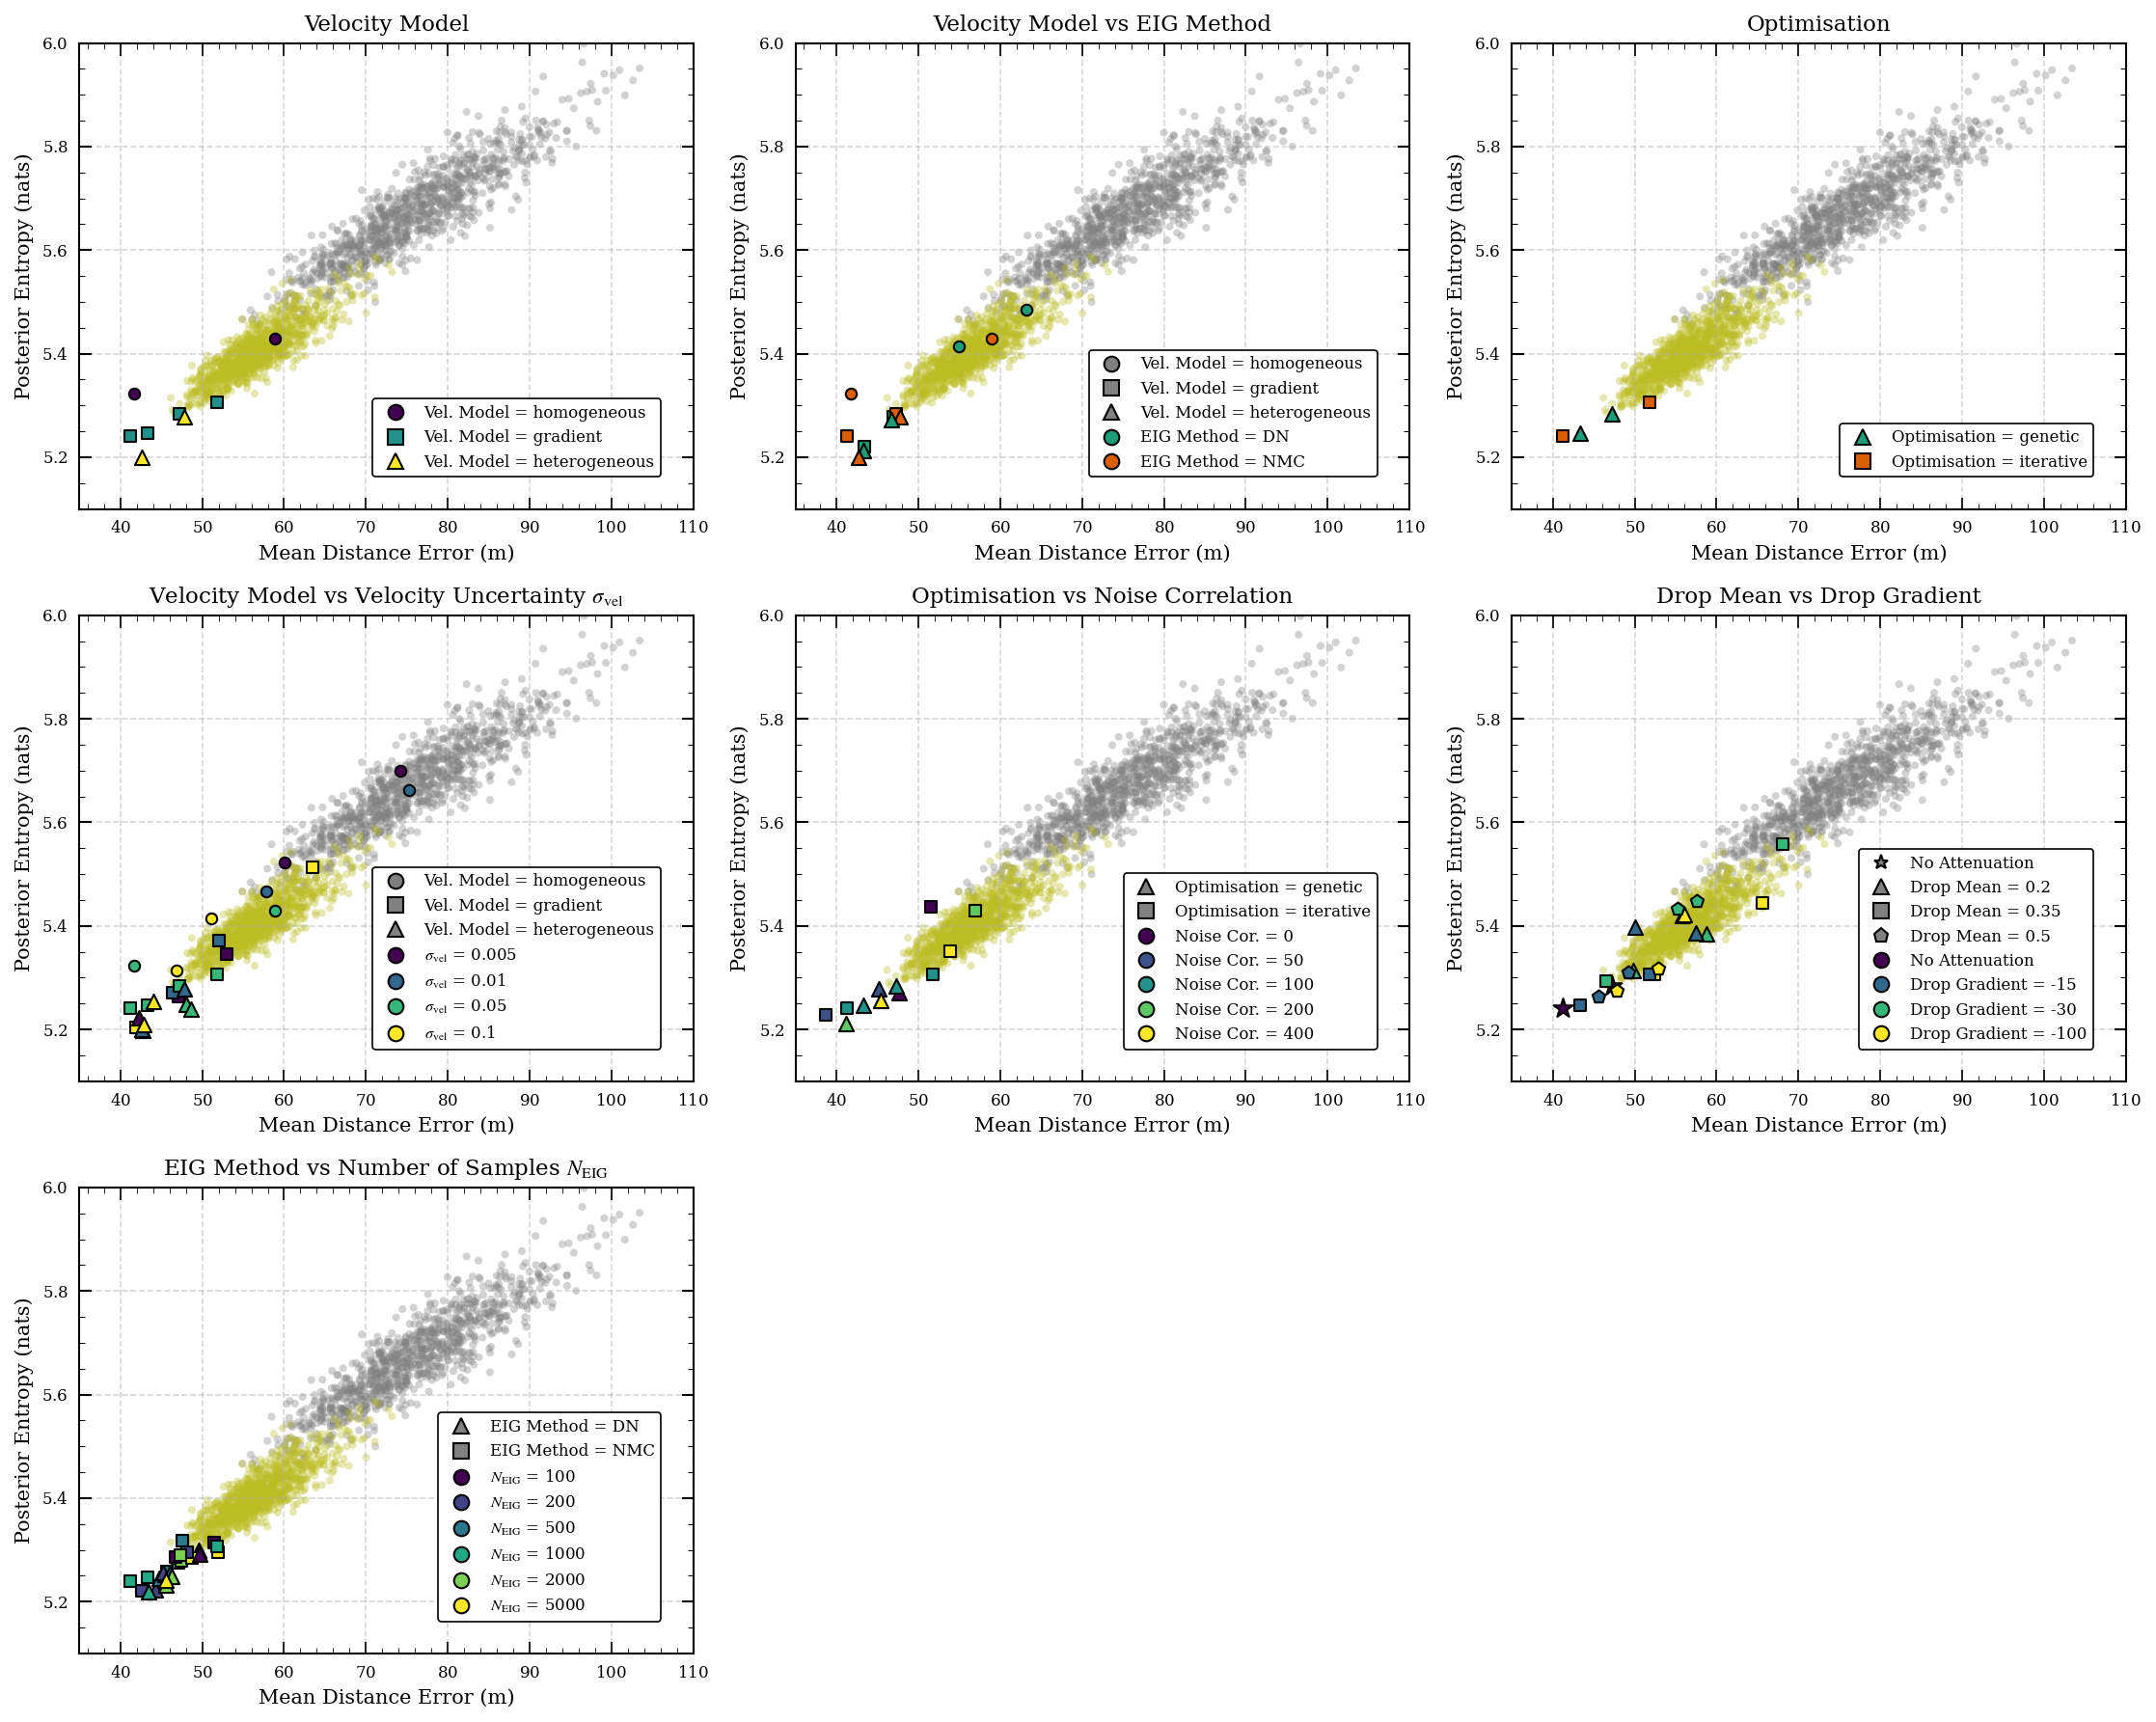

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Define scenario pairs to compare: [param1, param2]
scenarios = {
    ("velocity_model", "velocity_model")   : {'set_defaults': True},
    ("velocity_model", "EIG_method")       : {'set_defaults': True, 'attenuation': False},
    ("optimisation", "optimisation")       : {'set_defaults': True},

    ("velocity_model", "vel_sigma")        : {'set_defaults': True},
    ("optimisation", "noise_correlation")  : {'set_defaults': True},
    ("drop_mean", "drop_gradient")         : {'set_defaults': True},

    ("EIG_method", "EIG_N")                : {'set_defaults': True},
    ("model_prior", "model_prior")         : {'set_defaults': True},
}

def get_color_marker_dicts(param1, param2, values1, values2):
    # Markers for param1, colors for param2
    n1 = len(values1)
    n2 = len(values2)
    # Markers
    if n1 <= 3:
        markers = ["^", "s", "p"]
    elif n1 <= 4:
        markers = ["*", "^", "s", "p"]
    elif n1 <= 6:
        markers = ["^", "s", "p", "*", "P", "X"]
    else:
        markers = ["o"] * n1
    marker_dict = {v: markers[i % len(markers)] for i, v in enumerate(values1)}
    # Colors
    fixed_colors = ['#1b9e77', '#d95f02']
    if n2 <= 2:
        color_dict = {v: fixed_colors[i % len(fixed_colors)] for i, v in enumerate(values2)}
    else:
        cmap = plt.get_cmap("viridis", n2)
        color_dict = {v: cmap(i) for i, v in enumerate(values2)}
    return color_dict, marker_dict

n_scenarios = len(scenarios)
n_cols = 3
n_rows = int(np.ceil(n_scenarios / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes = axes.flatten()

for i, (param1, param2) in enumerate(scenarios):
    unique_vals1 = np.sort(stats_all[param1].unique())
    unique_vals2 = np.sort(stats_all[param2].unique())
    if param1 == "velocity_model":
        unique_vals1 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "velocity_model":
        unique_vals2 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "drop_gradient":
        unique_vals2 = unique_vals2[::-1]
    if len(unique_vals2) < 2 or len(unique_vals1) < 1:
        axes[i].set_visible(False)
        continue
    color_dict, marker_dict = get_color_marker_dicts(param1, param2, unique_vals1, unique_vals2)
    if param1 == "velocity_model":
        marker_dict = {
            'homogeneous': 'o',
            'gradient': 's',
            'heterogeneous': '^',
        }
    plot_combinations(
        axes[i],
        data=stats_all,
        x_quantity=x_quantity,
        y_quantity=y_quantity,
        param1=param1,
        param2=param2,
        color_dict=color_dict,
        marker_dict=marker_dict,
        title=f"{param2}" if param1 == param2 else f"{param1} vs {param2}",
        **scenarios[(param1, param2)],
    )

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [69]:
# scenarios = dict(
#     vel_homogeneous = dict(
#         name='velocity model: homogeneous',
#         interest_filters=dict(velocity_model='homogeneous', EIG_method='NMC', EIG_N=1000,
#         # vel_sigma=0.05, noise_correlation=100, drop_mean=0.0,
#          optimisation='genetic'))
#     ,
#     vel_gradient = dict(
#         name='velocity model: gradient',
#         interest_filters=dict(velocity_model='gradient', EIG_method='NMC', EIG_N=1000,
#         # vel_sigma=0.05, noise_correlation=100, drop_mean=0.0,
#          optimisation='genetic'))
#     ,
#     vel_heterogeneous = dict(
#         name='velocity model: heterogeneous',
#         interest_filters=dict(velocity_model='heterogeneous', EIG_method='NMC', EIG_N=1000,
#         # vel_sigma=0.05, noise_correlation=100, drop_mean=0.0,
#          optimisation='genetic'))
# )

# color_list = [
#     'cornflowerblue', 'royalblue', 'navy',
#     'forestgreen', 'limegreen', 'darkgreen',
#     'darkorange', 'orangered',
# ]


# # Plotting parameters from the example
# N_rec_min = 1
# N_rec_max = 15
# metric_to_plot = 'distance_mean'

# plot_data_collections = []
# plot_labels = []

# # Iterate through the defined scenarios
# for scenario_key, scenario_config in scenarios.items():
#     current_interest_filters = scenario_config.get('interest_filters', {})
#     current_ignore_filters = scenario_config.get('ignore_filters', {})

#     # Use get_summary_stats to filter and average data for the scenario
#     # get_summary_stats groups by scen_columns and calculates the mean of stat_columns
#     scenario_summary_df = get_summary_stats(
#         summary_df=summary_statistics,
#         interest_filters=current_interest_filters,
#         ignore_filters=current_ignore_filters,
#         N_min=N_rec_min,
#         N_max=N_rec_max,
#     )
    
#     # The metric_to_plot should be one of the stat_columns
#     if not scenario_summary_df.empty and metric_to_plot in scenario_summary_df.columns:
#         plot_data_collections.append(scenario_summary_df[metric_to_plot])
#         # Use the 'name' from scenario_config for labels, and replace underscores
#         label_name = scenario_config.get('name', scenario_key).replace('_', ' ')
#         # Add count of data points like in the example (len(stat))
#         plot_labels.append(f"{label_name} ({len(scenario_summary_df[metric_to_plot])})")
#     else:
#         label_name = scenario_config.get('name', scenario_key).replace('_', ' ')
#         plot_data_collections.append(pd.Series(dtype='float64')) 
#         plot_labels.append(f"{label_name} (No data)")

# # Create the plot, inspired by the example
# if plot_labels: # Check if there are any labels (means scenarios were processed)
#     fig, ax = plt.subplots(figsize=(8, 4)) # Matches example figsize

#     for i, data_series in enumerate(plot_data_collections):
#         if not data_series.empty:
#             # Plot range bar (min to max of the means for this scenario group)
#             ax.plot([data_series.min(), data_series.max()], [i, i], 
#                     color=color_list[i % len(color_list)], 
#                     linewidth=12.0, alpha=0.2)
            
#             # Plot individual mean data points (each point is a mean for a sub-configuration)
#             ax.scatter(data_series, np.full(len(data_series), i), 
#                        marker='x', color=color_list[i % len(color_list)], 
#                        s=100, alpha=1.0, zorder=10, linewidth=2.0)
#         # If data_series is empty, nothing is plotted for this row; the label indicates "No data"

#     ax.set_yticks(np.arange(len(plot_labels)))
#     ax.set_yticklabels(plot_labels)

#     ax.set_xlabel(f'Mean {metric_to_plot.replace("_", " ")} (m)')
#     # Title similar to the example
#     ax.set_title(f'Average {metric_to_plot.replace("_", " ")} over {N_rec_min}-{N_rec_max} receivers')

#     ax.invert_yaxis() # Common for this type of comparison plot
#     ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
#     ax.minorticks_on()
#     ax.grid(True, axis='x', linestyle=':', linewidth=0.5, which='minor', alpha=0.5)
        
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No scenarios processed or no data found for the defined scenarios.")